In [1]:
#解压test的图像
import zipfile
import os

# 定义文件路径
zip_file = "test.zip"  # 压缩文件
output_dir = "image"  # 解压到的目标文件夹

# 创建目标文件夹（如果不存在）
os.makedirs(output_dir, exist_ok=True)

# 解压缩
with zipfile.ZipFile(zip_file, 'r') as zip_ref:
    zip_ref.extractall(output_dir)

print(f"解压完成！文件已解压到 '{output_dir}' 文件夹。")


解压完成！文件已解压到 'image' 文件夹。


In [2]:
import os

# 指定文件夹路径
folder_path = "./image/test"

# 遍历文件夹下的所有文件
file_list = []
for root, dirs, files in os.walk(folder_path):
    for file in files:
        file_list.append(os.path.join(root, file))  # 记录文件的完整路径

# 打印所有文件路径
for file_path in file_list:
    print(file_path)


./image/test/1024x1024.jpg
./image/test/128x128.jpg
./image/test/256x256.jpg
./image/test/32x32.jpg
./image/test/64x64.jpg
./image/test/16x16.jpg
./image/test/512x512.jpg
./image/test/2048x2048.jpg


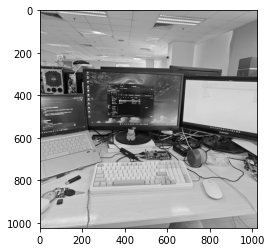

In [13]:
import cv2 as cv
from matplotlib import pyplot as plt
import numpy as np
import time
import copy
gray = cv.imread("./image/test/1024x1024.jpg", cv.IMREAD_GRAYSCALE)
plt.imshow(gray, cmap="gray")

In [14]:
from pynq import Overlay, allocate

overlay = Overlay("./design_1_wrapper.bit")
sobel = overlay.sobel_0

# allocate memory
rows, cols= gray.shape
input_buffer = allocate(shape=(rows*cols,), dtype='u1')
output_buffer = allocate(shape=(rows*cols,), dtype='u1')

# input
gray_new = np.uint8(gray)
np.copyto(input_buffer, gray_new.flatten())
sobel.register_map
sobel.register_map.rows = rows
sobel.register_map.cols = cols
dma = overlay.axi_dma_0
print("import done")

import done


Time cost with handcoded IP：0.03879690170288086s


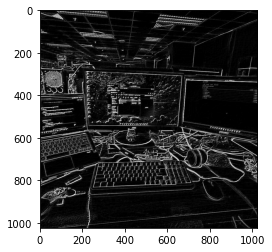

In [15]:
import time

sobel.register_map.CTRL.AP_START = 1

start_time = time.time()

dma.sendchannel.transfer(input_buffer)
dma.recvchannel.transfer(output_buffer)
dma.sendchannel.wait() # wait for send channel
dma.recvchannel.wait() # wait for recv channel

end_time = time.time()

time_handcoded = end_time - start_time
print("Time cost with handcoded IP：{}s".format(time_handcoded))
# G_handcoded = copy.deepcopy(output_buffer.reshape(rows, cols))
G_handcoded = output_buffer.reshape(rows, cols)
# save image
plt.savefig("output/1024_ip.png")  

plt.imshow(G_handcoded,cmap='gray')

Time cost with software：0.32528114318847656s


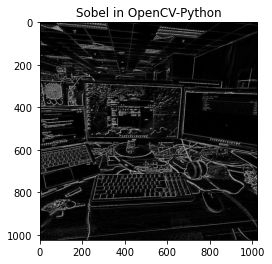

In [16]:
# Apply Sobel filter to get the gradients in X and Y direction
# The Sobel operator calculates the gradient of the image intensity at each pixel

start_time_python = time.time()

Gx = cv.Sobel(gray, cv.CV_16U, 1, 0, ksize=3)  # Gradient in X direction
Gy = cv.Sobel(gray, cv.CV_16U, 0, 1, ksize=3)  # Gradient in Y direction

# Compute the gradient magnitude
G = np.sqrt(Gx**2 + Gy**2)
# Convert to 8-bit image for display
G_python = G.astype(np.uint8)

end_time_python = time.time()

time_python = end_time_python - start_time_python

print("Time cost with software：{}s".format(time_python))

plt.title("Sobel in OpenCV-Python")
# save image
plt.savefig("output/1024_python.png")  

plt.imshow(G_python, cmap="gray")

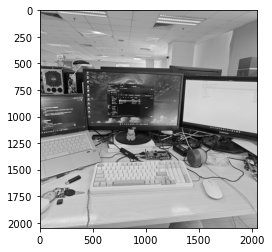

In [50]:
import cv2 as cv
from matplotlib import pyplot as plt
import numpy as np
import time
import copy
gray = cv.imread("./image/test/2048x2048.jpg", cv.IMREAD_GRAYSCALE)
plt.imshow(gray, cmap="gray")

In [51]:
from pynq import Overlay, allocate

overlay = Overlay("./design_1_wrapper.bit")
sobel = overlay.sobel_0

# allocate memory
rows, cols= gray.shape
input_buffer = allocate(shape=(rows*cols,), dtype='u1')
output_buffer = allocate(shape=(rows*cols,), dtype='u1')

# input
gray_new = np.uint8(gray)
np.copyto(input_buffer, gray_new.flatten())
sobel.register_map
sobel.register_map.rows = rows
sobel.register_map.cols = cols
dma = overlay.axi_dma_0
print("import done")

import done


Time cost with handcoded IP：0.13857674598693848s


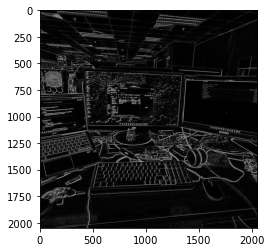

In [52]:
import time

sobel.register_map.CTRL.AP_START = 1

start_time = time.time()

dma.sendchannel.transfer(input_buffer)
dma.recvchannel.transfer(output_buffer)
dma.sendchannel.wait() # wait for send channel
dma.recvchannel.wait() # wait for recv channel

end_time = time.time()

time_handcoded = end_time - start_time
print("Time cost with handcoded IP：{}s".format(time_handcoded))
# G_handcoded = copy.deepcopy(output_buffer.reshape(rows, cols))
G_handcoded = output_buffer.reshape(rows, cols) 

plt.imshow(G_handcoded,cmap='gray')

Time cost with software：1.3372910022735596s


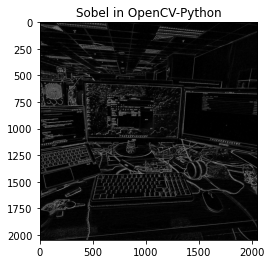

In [53]:
# Apply Sobel filter to get the gradients in X and Y direction
# The Sobel operator calculates the gradient of the image intensity at each pixel

start_time_python = time.time()

Gx = cv.Sobel(gray, cv.CV_16U, 1, 0, ksize=3)  # Gradient in X direction
Gy = cv.Sobel(gray, cv.CV_16U, 0, 1, ksize=3)  # Gradient in Y direction

# Compute the gradient magnitude
G = np.sqrt(Gx**2 + Gy**2)
# Convert to 8-bit image for display
G_python = G.astype(np.uint8)

end_time_python = time.time()

time_python = end_time_python - start_time_python

print("Time cost with software：{}s".format(time_python))

plt.title("Sobel in OpenCV-Python")

plt.imshow(G_python, cmap="gray")